In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
dz = gpd.read_file("data/DZ2021.shp")

In [3]:
dz.head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39..."
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39..."
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39..."
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39..."
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39..."


In [4]:
pop = pd.read_excel("data/census-2021-ms-a01.xlsx")

In [5]:
pop.head()

,Unnamed: 0,Unnamed: 1
0,National Statistics Theme:,Census 2021
1,Data subset:,Demography
2,Dataset title:,Usual resident population MS-A01
3,Coverage:,"Data Zone, Super Data Zone, Settlement, Ward, ..."
4,Source:,NISRA


In [6]:
pop = pd.read_excel(
    "data/census-2021-ms-a01.xlsx",
    sheet_name="DZ",
    skiprows=5
)

pop.head()

,Geography,Geography Code,All usual residents,Access census area explorer
0,Dunsilly_A1,N20000001,738,Dunsilly_A1 DZ profile
1,Dunsilly_B1,N20000002,331,Dunsilly_B1 DZ profile
2,Dunsilly_A2,N20000003,365,Dunsilly_A2 DZ profile
3,Dunsilly_A3,N20000004,663,Dunsilly_A3 DZ profile
4,Dunsilly_B2,N20000005,676,Dunsilly_B2 DZ profile


In [7]:
dz.columns

Index(['DZ2021_cd', 'DZ2021_nm', 'SDZ2021_cd', 'SDZ2021_nm', 'DEA2014_cd',
       'DEA2014_nm', 'LGD2014_cd', 'LGD2014_nm', 'Area_ha', 'Perim_km',
       'geometry'],
      dtype='str')

In [8]:
pop.columns

Index(['Geography', 'Geography Code', 'All usual residents',
       'Access census area explorer'],
      dtype='str')

In [9]:
dz = dz.merge(
    pop,
    left_on="DZ2021_cd",
    right_on="Geography Code"
)

In [10]:
dz.head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,Geography,Geography Code,All usual residents,Access census area explorer
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39...",Dunsilly_A1,N20000001,738,Dunsilly_A1 DZ profile
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39...",Dunsilly_B1,N20000002,331,Dunsilly_B1 DZ profile
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39...",Dunsilly_A2,N20000003,365,Dunsilly_A2 DZ profile
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39...",Dunsilly_A3,N20000004,663,Dunsilly_A3 DZ profile
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39...",Dunsilly_B2,N20000005,676,Dunsilly_B2 DZ profile


<Axes: >

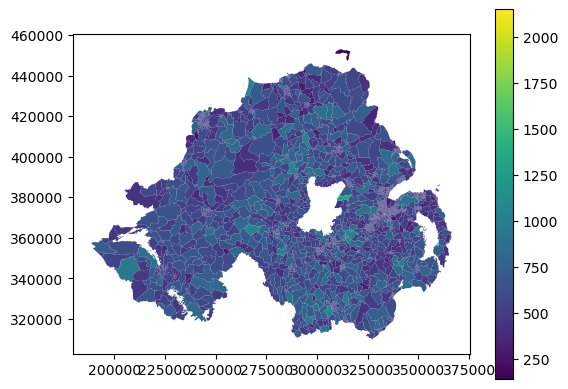

In [11]:
dz.plot(column="All usual residents", legend=True)

In [12]:
import osmnx as ox

In [13]:
# Reproject to latitude/longitude for OSM queries
dz_wgs84 = dz.to_crs("EPSG:4326")

# Check bounds in lat/lon
bbox = dz_wgs84.total_bounds

In [14]:
# Download hospital locations from OpenStreetMap using WGS84 bounds
hospitals = ox.features_from_bbox(
    bbox,
    tags={"amenity": "hospital"}
)

hospitals.head()

geometry  \
element  id                                                               
node     1376200677                           POINT (-7.28047 55.01356)   
         1376200841                           POINT (-7.28268 55.01539)   
         2545693040                           POINT (-7.48323 54.83127)   
         13196719821                             POINT (-5.9395 54.608)   
relation 5342502      POLYGON ((-6.40968 54.43304, -6.41098 54.43286...   

                       amenity healthcare                        name  \
element  id                                                             
node     1376200677   hospital   hospital          Waterside Hospital   
         1376200841   hospital   hospital                    Lakeview   
         2545693040   hospital   hospital  Lifford Community Hospital   
         13196719821  hospital   hospital              Macular Clinic   
relation 5342502      hospital   hospital     Craigavon Area Hospital   

                     emergency  addr:city addr:housenumber addr:postcode  \
element  id                                                                
node     1376200677         no        NaN              NaN           NaN   
         1376200841         no        NaN              NaN           NaN   
         2545693040        NaN        NaN              NaN           NaN   
         13196719821       NaN        NaN              NaN           NaN   
relation 5342502           yes  Portadown               68      BT63 5QQ   

                      addr:street description  ... building wheelchair  \
element  id                                    ...                       
node     1376200677           NaN         NaN  ...      NaN        NaN   
         1376200841           NaN         NaN  ...      NaN        NaN   
         2545693040           NaN         NaN  ...      NaN        NaN   
         13196719821          NaN         NaN  ...      NaN        NaN   
relation 5342502      Lurgan Road         NaN  ...      NaN        NaN   

                     source:geometry check_date contact:website          type  \
element  id                                                                     
node     1376200677              NaN        NaN             NaN           NaN   
         1376200841              NaN        NaN             NaN           NaN   
         2545693040              NaN        NaN             NaN           NaN   
         13196719821             NaN        NaN             NaN           NaN   
relation 5342502                 NaN        NaN             NaN  multipolygon   

                     HSE_code HSE_hgid HSE_hgroup HSE_region  
element  id                                                   
node     1376200677       NaN      NaN        NaN        NaN  
         1376200841       NaN      NaN        NaN        NaN  
         2545693040       NaN      NaN        NaN        NaN  
         13196719821      NaN      NaN        NaN        NaN  
relation 5342502          NaN      NaN        NaN        NaN  

[5 rows x 42 columns]

In [15]:
# Check hospital geometry types
hospitals.geometry.type.value_counts()

Polygon    58
Point       4
Name: count, dtype: int64

In [16]:
# Keep all relevant hospital geometries
hospitals = hospitals[hospitals.geometry.type.isin(["Point", "Polygon", "MultiPolygon"])]

In [17]:
# Create a representative point for each hospital
hospitals["hospital_point"] = hospitals.geometry.representative_point()

# Use these points as geometry
hospitals = hospitals.set_geometry("hospital_point")

In [18]:
# Match coordinate system with Data Zones
hospitals = hospitals.to_crs(dz.crs)

In [19]:
# Keep only hospitals located within the Northern Ireland study area.
# 'intersects' is used instead of 'within' to avoid excluding boundary cases.
hospitals = hospitals[hospitals.intersects(dz.union_all())]

In [20]:
# Check number of hospitals after cleaning
len(hospitals)

41

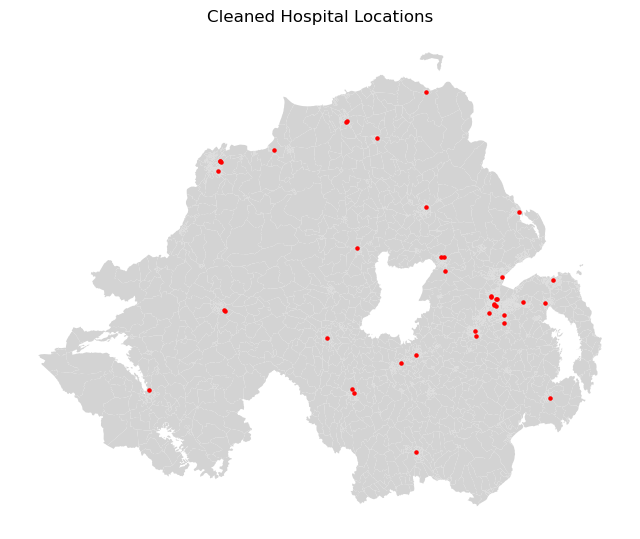

In [21]:
import matplotlib.pyplot as plt

# Plot Data Zones as background map
ax = dz.plot(color="lightgrey", figsize=(8,8))

# Overlay hospital locations to visually check they are correctly positioned
hospitals.plot(ax=ax, color="red", markersize=5)

# Add title for map clarity
ax.set_title("Cleaned Hospital Locations")

# Remove axis for cleaner map display
ax.axis("off")

plt.show()